Smother Experiment: comparing the influence of a die-off of coastal invertebrates and birds as a result of smothering from Bunker C whole oil to the water soluble fraction of PAH contamination only. Results are 3-day Atlantis output from 2019-2022

Half lives

| PAH Concentration	|	Naphthalene |	Phenanthrene | Pyrene |	Benzo(a)pyrene |
|-------------------|---------------|-----------------|--------|----------|
| Half life (secs)	|	259200 |	3628800	| 20476800	| 19353600 |
| Half life (days)	|	3	| 42 |	237 |	224 |

In [1]:
import os
import re
import xarray as xr
import numpy as np
import itertools
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.dates as mdates
from pathlib import Path
from datetime import timedelta
import matplotlib.pyplot as plt
import ssam_groups as groups

In [2]:
# Read in salish sea atlantis output files.
control_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/Control/')
#control_paths = sorted([p for p in control_root.glob('v6719_60d/outputSalishSea.nc')])
control_paths = sorted([p for p in control_root.glob('highres-control-3y-2*/outputSalishSea.nc')])
for path in control_paths:
    print(path.parent.stem)

highres-control-3y-2019-2022
highres-control-3y-2029-2032
highres-control-3y-2039-2042


In [3]:
control_datasets = [xr.open_dataset(cfile,decode_cf=True) for cfile in control_paths]

control_file = "/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/Control/highres-control-3y-2019-2022/outputSalishSea.nc"
control = xr.open_dataset(str(control_file), decode_cf=True)
time = np.ma.filled(control.variables['t'])

In [4]:
scenario_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/Smother-test/')

In [5]:
# start and end time of data display, after burn-in
start = 0
end = 365

## All Scenarios

In [6]:
Turn_Point = [8, 9, 33, 34, 37, 60, 66]
Active_Pass = [33, 60, 63]
English_Bay = [75]
Jstrait = [1, 2] 

In [7]:
hex_colour = '#2F61A4' # alt #8CB7D7
hatches = ['oo', '///', 'xx', '++']

In [8]:
line_styles = itertools.cycle(('-', '--', '-.', ':'))#,(5, (10, 3)),
#    (0, (3, 1, 1, 1)),(0, (1, 1)),(0, (3, 10, 1, 10, 1, 10))))

In [9]:

scenario_paths = sorted([p for p in scenario_root.glob('6a_2019-07-16_2*/outputSalishSea.nc')])
scenario_names = []
for path in scenario_paths:
    print(path.parent.stem)
    nm = str(path.parent.stem).split(sep='_')
    if nm[0] == '4a':
        scenario_loc = 'AP'
    elif nm[0] == '5b':
        scenario_loc = 'TP'
    elif nm[0] == '6a':
        scenario_loc = 'EB'
    elif nm[0] == '7a':
        scenario_loc = 'JF'
    scenario_names.append(scenario_loc+'-'+str(nm[1])+'-'+str(nm[2]))

6a_2019-07-16_2019-2022
6a_2019-07-16_2039-2042


In [10]:
print(scenario_names)

['EB-2019-07-16-2019-2022', 'EB-2019-07-16-2039-2042']


In [11]:
scenario_datasets = [xr.open_dataset(scen,decode_cf=True) for scen in scenario_paths]

### PAH concentrations

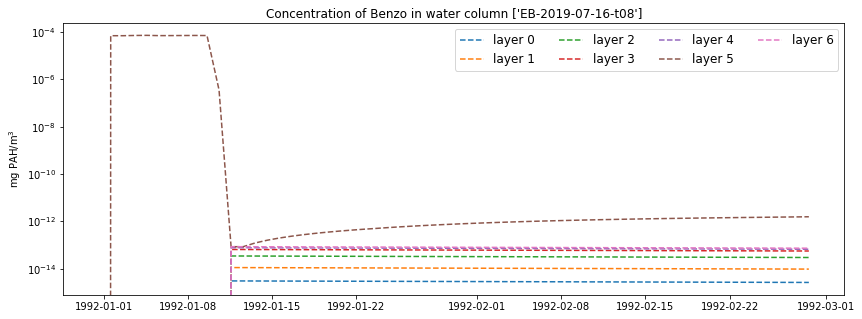

In [32]:
fig, ax = plt.subplots(figsize = (14,5))
for scenario, name in zip(scenario_datasets[5:6],scenario_names[5:6]):
    contam_tbl = scenario.variables['Benzo'][start:end,:,:]
    contam_t = contam_tbl.sum(axis=1)
    ax.semilogy(scenario.t[start:end], contam_t, linestyle=next(line_styles))
ax.set_title('Concentration of Benzo in water column '+str(scenario_names[5:6]), fontsize = 12)
ax.set_ylabel('mg PAH/m$^3$')
ax.legend(['layer 0', 'layer 1', 'layer 2', 'layer 3', 'layer 4', 'layer 5', 'layer 6'], fontsize=12, ncol=4); #loc='upper left', bbox_to_anchor=(1.05, 1), loc='upper center', 

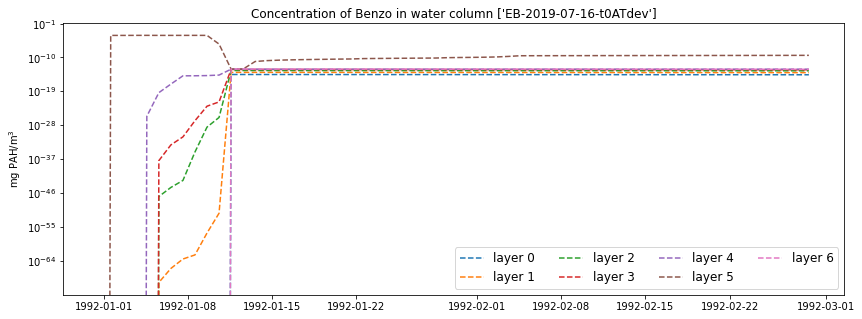

In [12]:
fig, ax = plt.subplots(figsize = (14,5))
for scenario, name in zip(scenario_datasets[9:10],scenario_names[9:10]):
    contam_tbl = scenario.variables['Benzo'][start:end,:,:]
    contam_t = contam_tbl.sum(axis=1)
    ax.semilogy(scenario.t[start:end], contam_t, linestyle=next(line_styles))
ax.set_title('Concentration of Benzo in water column '+str(scenario_names[9:10]), fontsize = 12)
ax.set_ylabel('mg PAH/m$^3$')
ax.legend(['layer 0', 'layer 1', 'layer 2', 'layer 3', 'layer 4', 'layer 5', 'layer 6'], fontsize=12, ncol=4); #loc='upper left', bbox_to_anchor=(1.05, 1), loc='upper center', 

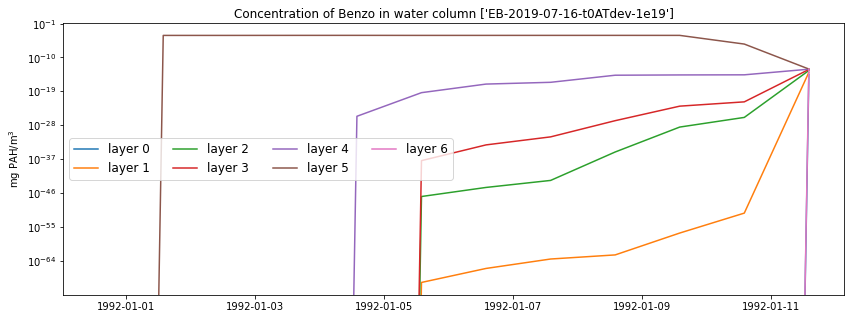

In [11]:
fig, ax = plt.subplots(figsize = (14,5))
for scenario, name in zip(scenario_datasets[10:11],scenario_names[10:11]):
    contam_tbl = scenario.variables['Benzo'][start:end,:,:]
    contam_t = contam_tbl.sum(axis=1)
    ax.semilogy(scenario.t[start:end], contam_t, linestyle=next(line_styles))
ax.set_title('Concentration of Benzo in water column '+str(scenario_names[10:11]), fontsize = 12)
ax.set_ylabel('mg PAH/m$^3$')
ax.legend(['layer 0', 'layer 1', 'layer 2', 'layer 3', 'layer 4', 'layer 5', 'layer 6'], fontsize=12, ncol=4); #loc='upper left', bbox_to_anchor=(1.05, 1), loc='upper center', 

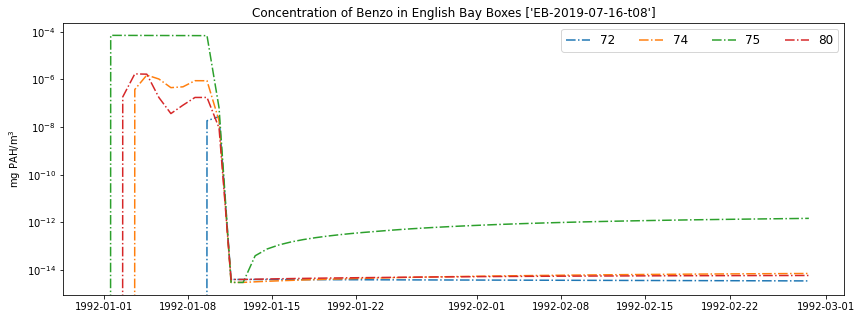

In [33]:
fig, ax = plt.subplots(figsize = (14,5))
for scenario, name in zip(scenario_datasets[5:6],scenario_names[5:6]):
    contam_tbl = scenario.variables['Benzo'][start:end,English_Bay,:]
    contam_t = contam_tbl.sum(axis=2)
    ax.semilogy(scenario.t[start:end], contam_t, linestyle=next(line_styles))
ax.set_title('Concentration of Benzo in English Bay Boxes '+str(scenario_names[5:6]), fontsize = 12)
ax.set_ylabel('mg PAH/m$^3$')
ax.legend(English_Bay, fontsize=12, ncol=4); #loc='upper left', bbox_to_anchor=(1.05, 1), loc='upper center', 

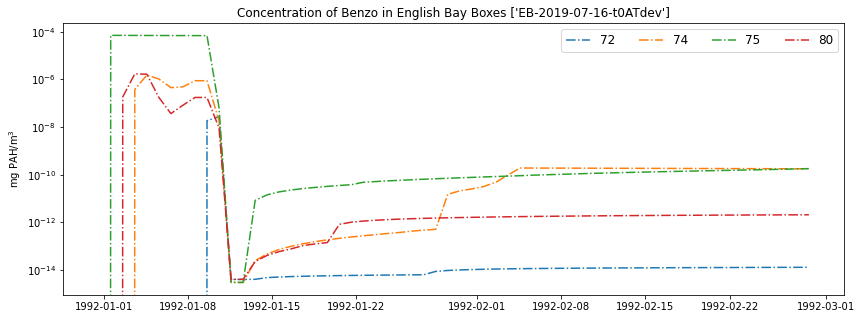

In [13]:
fig, ax = plt.subplots(figsize = (14,5))
for scenario, name in zip(scenario_datasets[9:10],scenario_names[9:10]):
    contam_tbl = scenario.variables['Benzo'][start:end,English_Bay,:]
    contam_t = contam_tbl.sum(axis=2)
    ax.semilogy(scenario.t[start:end], contam_t, linestyle=next(line_styles))
ax.set_title('Concentration of Benzo in English Bay Boxes '+str(scenario_names[9:10]), fontsize = 12)
ax.set_ylabel('mg PAH/m$^3$')
ax.legend(English_Bay, fontsize=12, ncol=4); #loc='upper left', bbox_to_anchor=(1.05, 1), loc='upper center', 

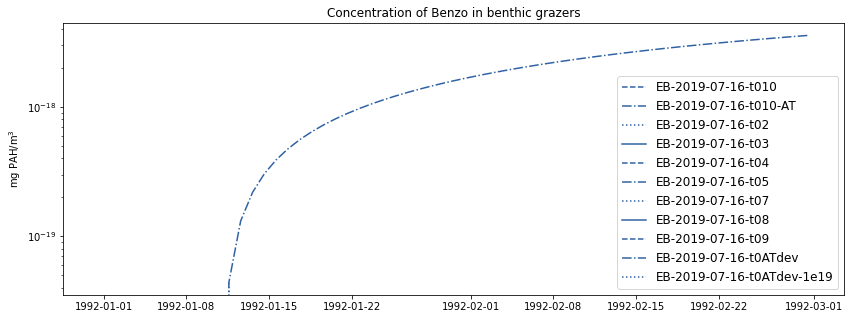

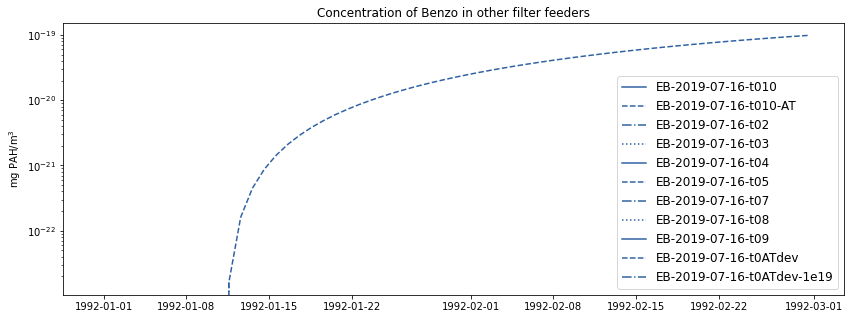

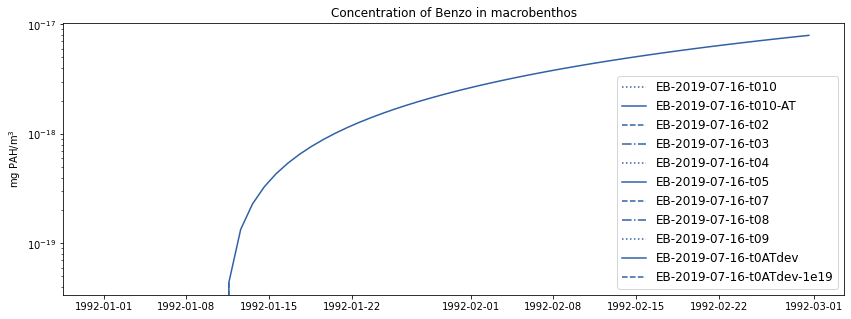

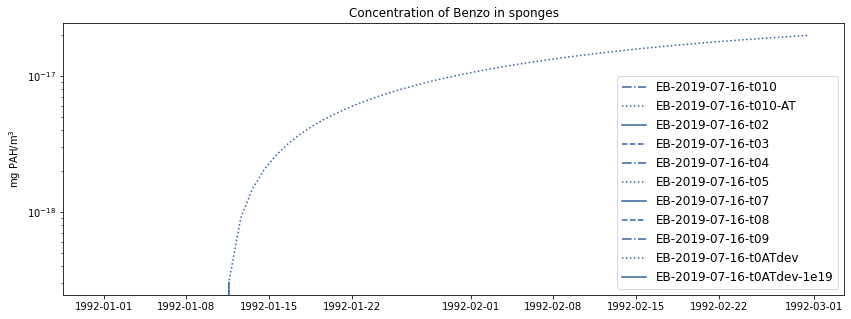

/home/rlovindeer/conda_envs/salishsea-tools/lib/python3.9/site-packages/matplotlib_inline/backend_inline.py:234: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  for label in axis.get_ticklabels()])


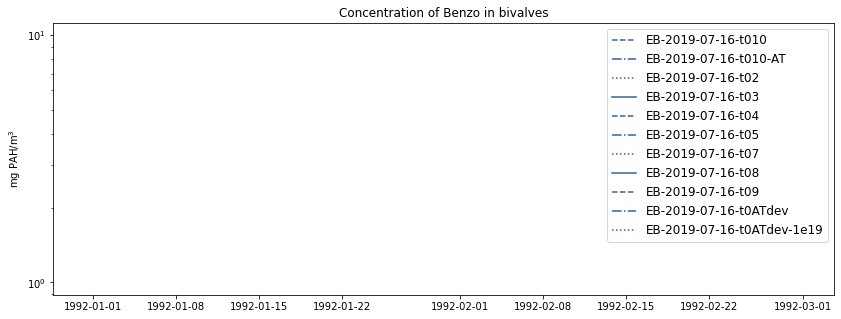

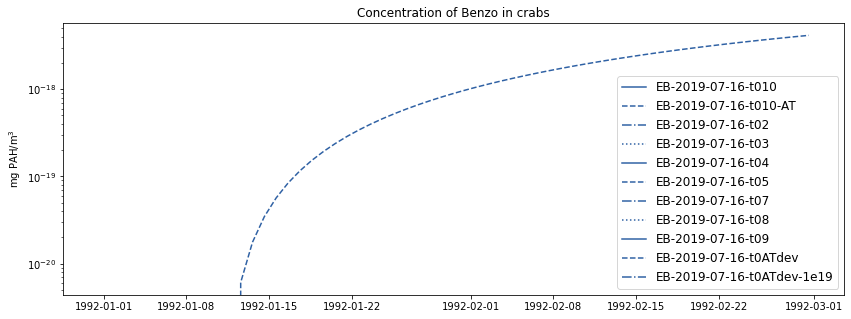

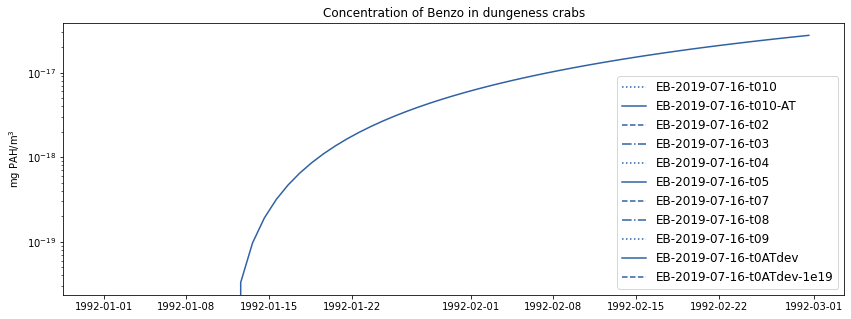

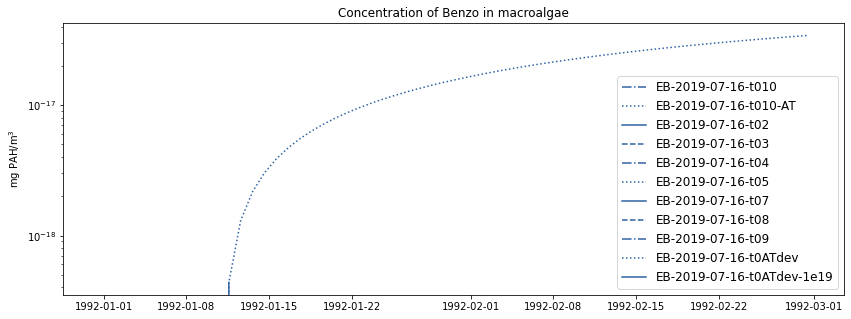

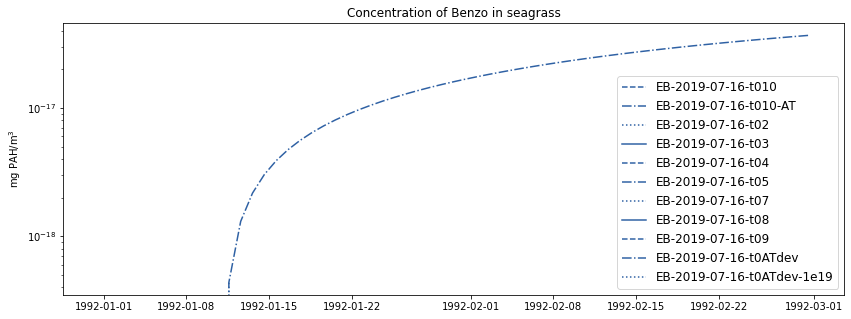

In [12]:
boxes = groups.salish_sea
for species in groups.benthos:
    fig, ax = plt.subplots(figsize = (14,5))
    for scenario, name in zip(scenario_datasets,scenario_names):
        contam_tb = scenario.variables[groups.benthos[species]+'_Benzo'][:,boxes]
        contam_t = contam_tb.sum(axis=(1))
        if 'AP' in name:
            hex_colour = '#863092'
        elif 'TP' in name:
            hex_colour = '#6DB48E'
        elif 'EB' in name:
            hex_colour = '#2F61A4'
        elif 'JF' in name:
            hex_colour = '#A27170'
        ax.semilogy(scenario.t, contam_t, color=hex_colour, linestyle=next(line_styles))
    ax.set_title('Concentration of Benzo in '+ species, fontsize = 12)
    ax.set_ylabel('mg PAH/m$^3$')
    ax.legend(scenario_names, fontsize=12, ncol=1);

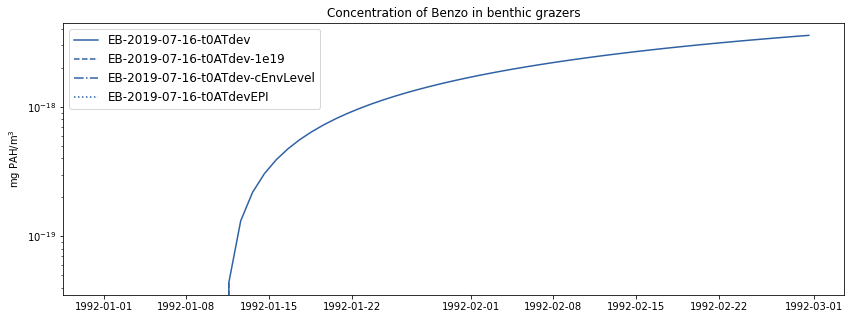

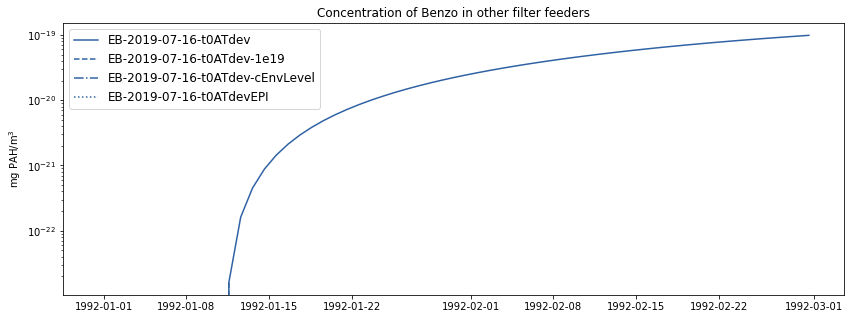

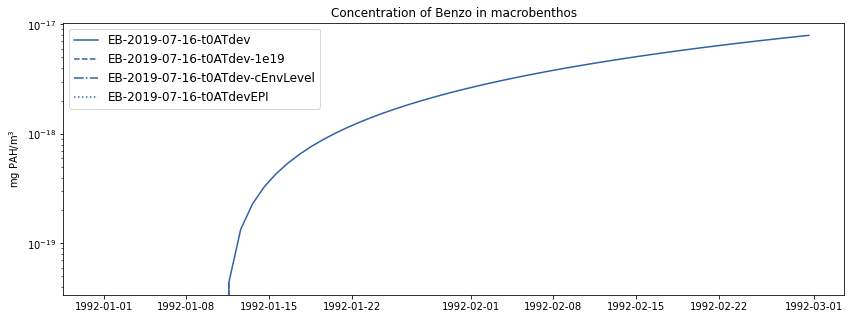

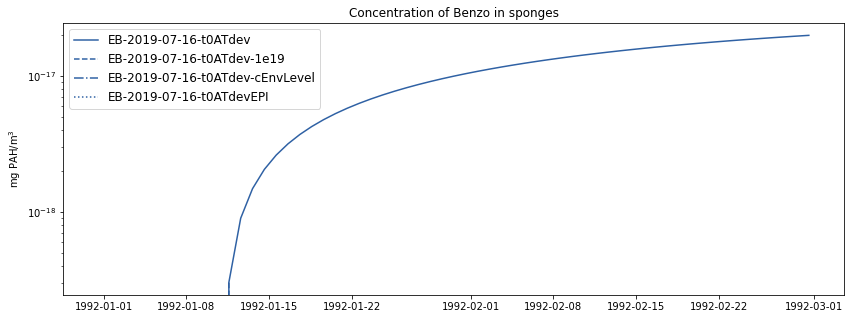

/home/rlovindeer/conda_envs/salishsea-tools/lib/python3.9/site-packages/matplotlib_inline/backend_inline.py:234: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  for label in axis.get_ticklabels()])


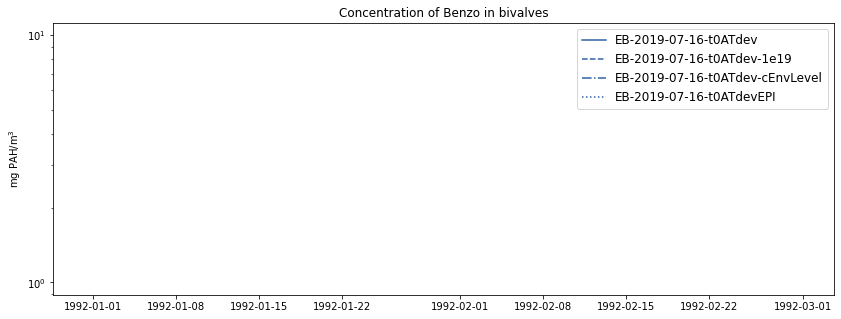

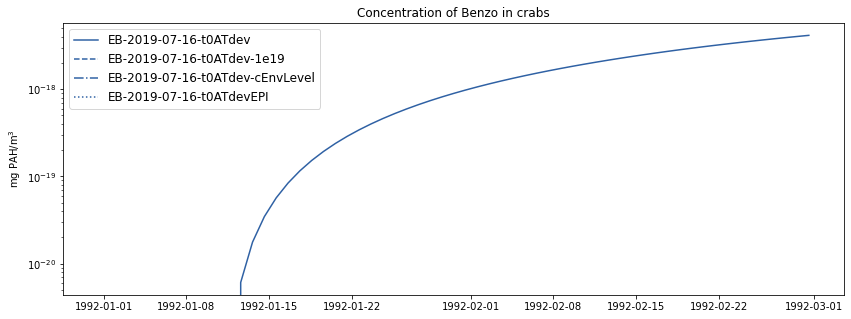

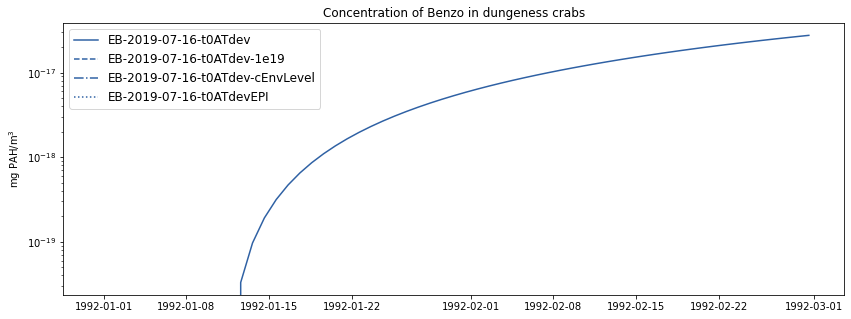

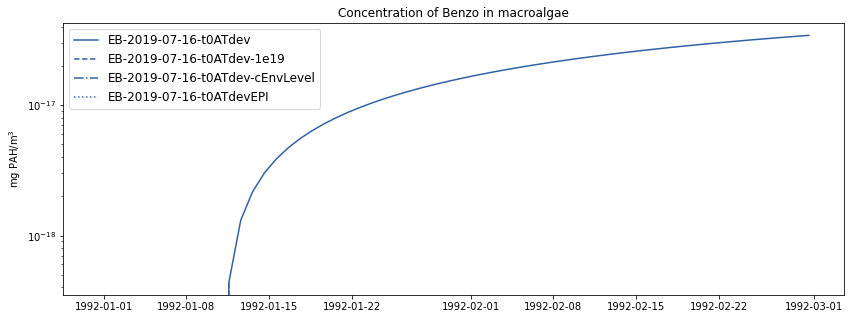

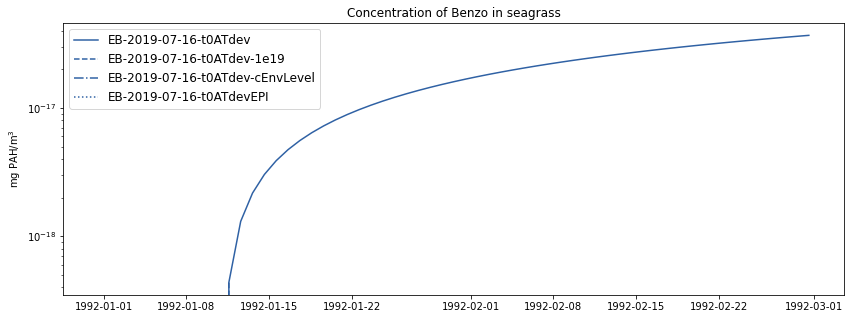

In [14]:
boxes = groups.salish_sea
for species in groups.benthos:
    fig, ax = plt.subplots(figsize = (14,5))
    for scenario, name in zip(scenario_datasets,scenario_names):
        contam_tb = scenario.variables[groups.benthos[species]+'_Benzo'][:,boxes]
        contam_t = contam_tb.sum(axis=(1))
        if 'AP' in name:
            hex_colour = '#863092'
        elif 'TP' in name:
            hex_colour = '#6DB48E'
        elif 'EB' in name:
            hex_colour = '#2F61A4'
        elif 'JF' in name:
            hex_colour = '#A27170'
        ax.semilogy(scenario.t, contam_t, color=hex_colour, linestyle=next(line_styles))
    ax.set_title('Concentration of Benzo in '+ species, fontsize = 12)
    ax.set_ylabel('mg PAH/m$^3$')
    ax.legend(scenario_names, fontsize=12, ncol=1);

### Impacts

In [12]:
def plot_benthic_biomass(bio_group, scenario_datasets, scenario_paths, control, boxes=groups.salish_sea, y_min=None, y_max=None):

    fig = plt.figure(figsize=(18, 18), facecolor='white')
    gs = plt.GridSpec(3, 3, wspace=0.2, hspace=0.2, width_ratios=[1,1,1], height_ratios=[1, 1, 1], )
    line_styles = itertools.cycle(('-', '--', '-.', ':',(5, (10, 3)),
    (0, (3, 1, 1, 1)),(0, (1, 1)),(0, (3, 10, 1, 10, 1, 10))))

    for species in bio_group:
        names = ['control']
        bio_index = (list(bio_group).index(species))
        if bio_index < 3:
            position = 0, bio_index
        elif bio_index > 5: 
            position = 2, bio_index-6
        else :
            position = 1, bio_index-3
        ax = fig.add_subplot(gs[position])

        pelagic_control = np.ma.filled(control.variables[bio_group[species] + '_N'][:,boxes], np.nan)
        pelagic_control = pelagic_control.sum(axis=1)+groups.base_biomass[bio_group[species]]
        ax.plot(control.t, pelagic_control, 'k')
    
        for scenario, path in zip(scenario_datasets, scenario_paths):
            nm = str(path.parent.stem).split(sep='_')
            scenario_name = 'EB-'+nm[2]  
            names.append(scenario_name)

            pelagic_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][:,boxes], np.nan) # tonnes
            pelagic_oiled = pelagic_oiled.sum(axis=1)+groups.base_biomass[bio_group[species]]
            ax.plot(scenario.t, pelagic_oiled, linewidth = 2, linestyle=next(line_styles),) #color=hex_colour,linestyle=next(line_styles)
        
        ax.set_ylabel('Biomass', fontsize=12)
        ax.set_title(species)
        ax.set_ylim([y_min, y_max])
    ax.legend(names, fontsize=12); #bbox_to_anchor=(1.05, 1)

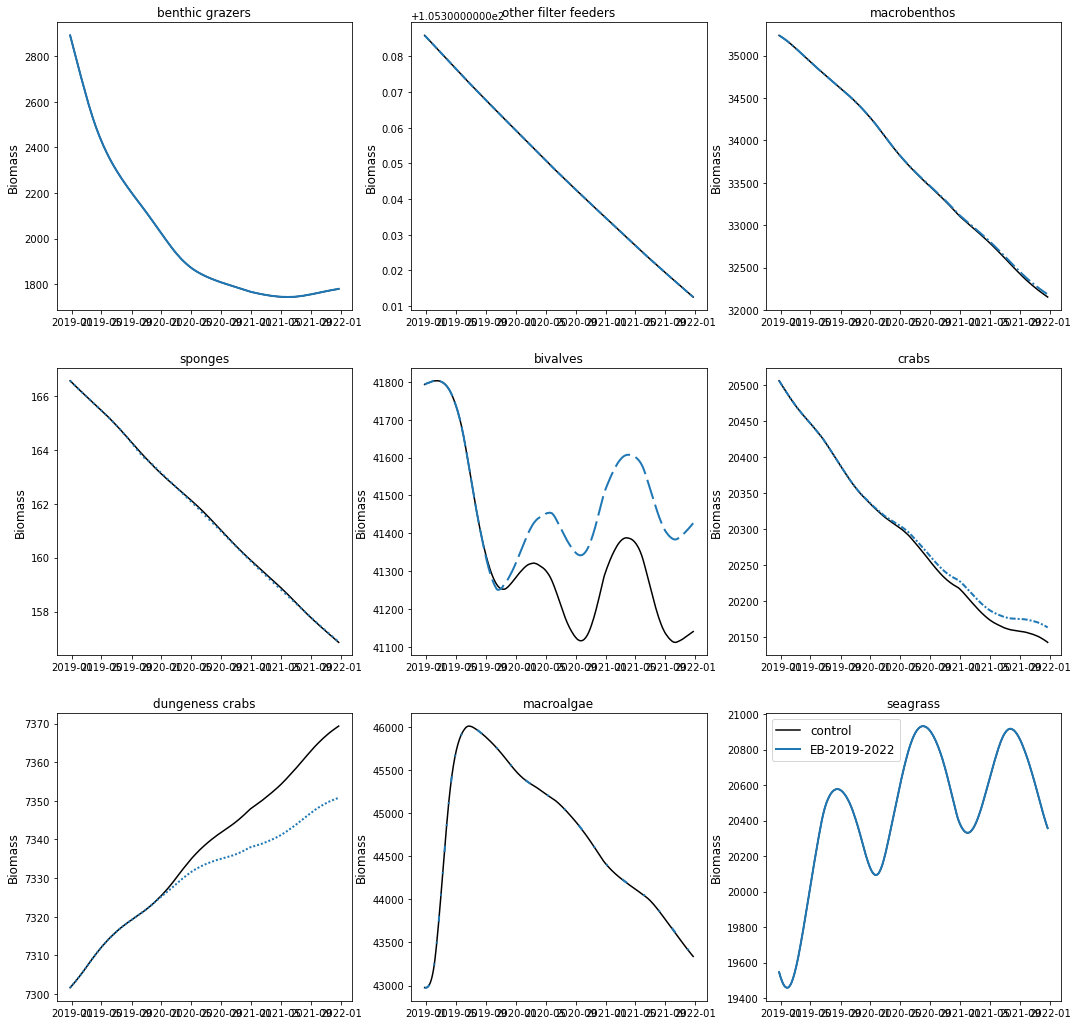

In [13]:
# 2019-2022 using native smothring code
for control in control_datasets[0:1]:
    plot_benthic_biomass(groups.benthos, scenario_datasets[0:1], scenario_paths[0:1], control, boxes=groups.salish_sea)

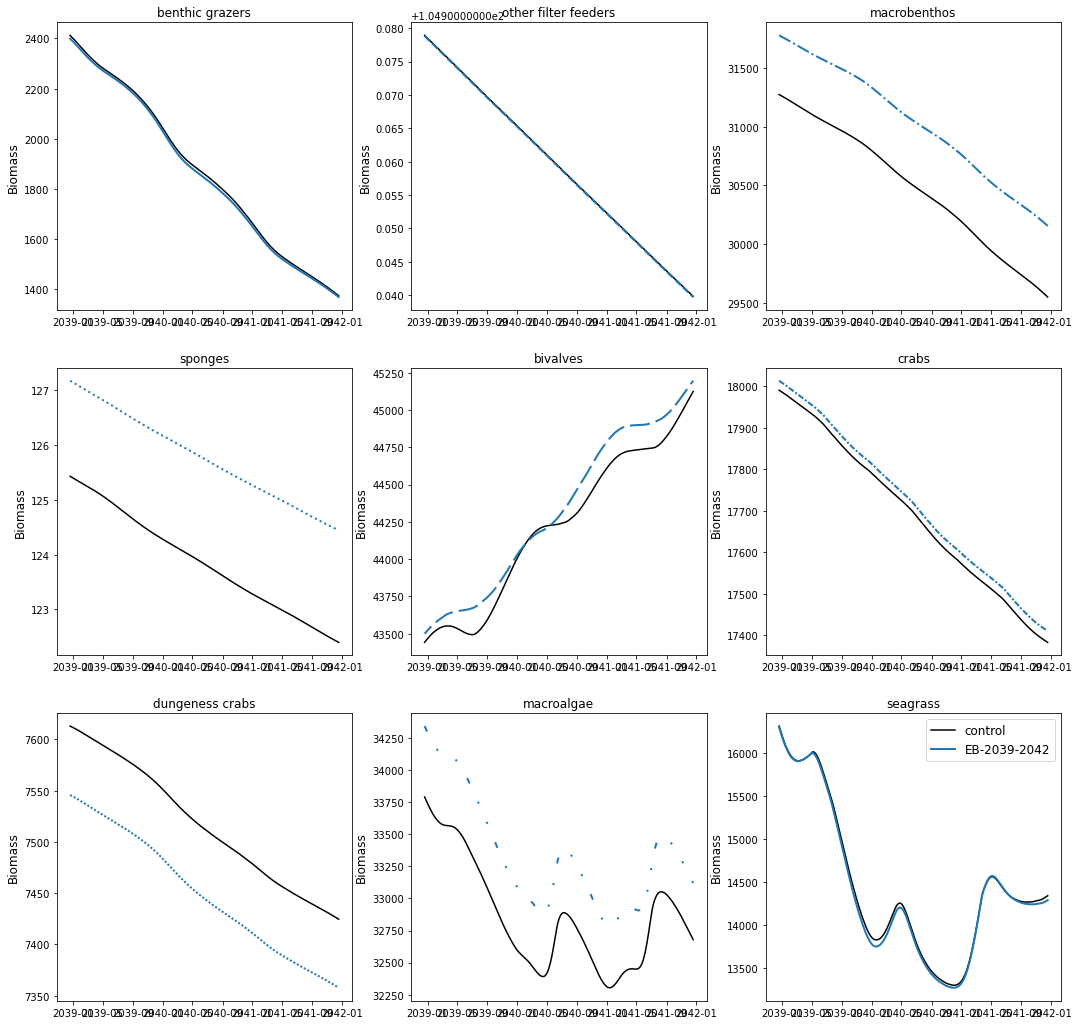

In [18]:
# 2039-2042 using native smothring code
for control in control_datasets[2:3]:
    plot_benthic_biomass(groups.benthos, scenario_datasets[1:2], scenario_paths[1:2], control, boxes=groups.salish_sea)

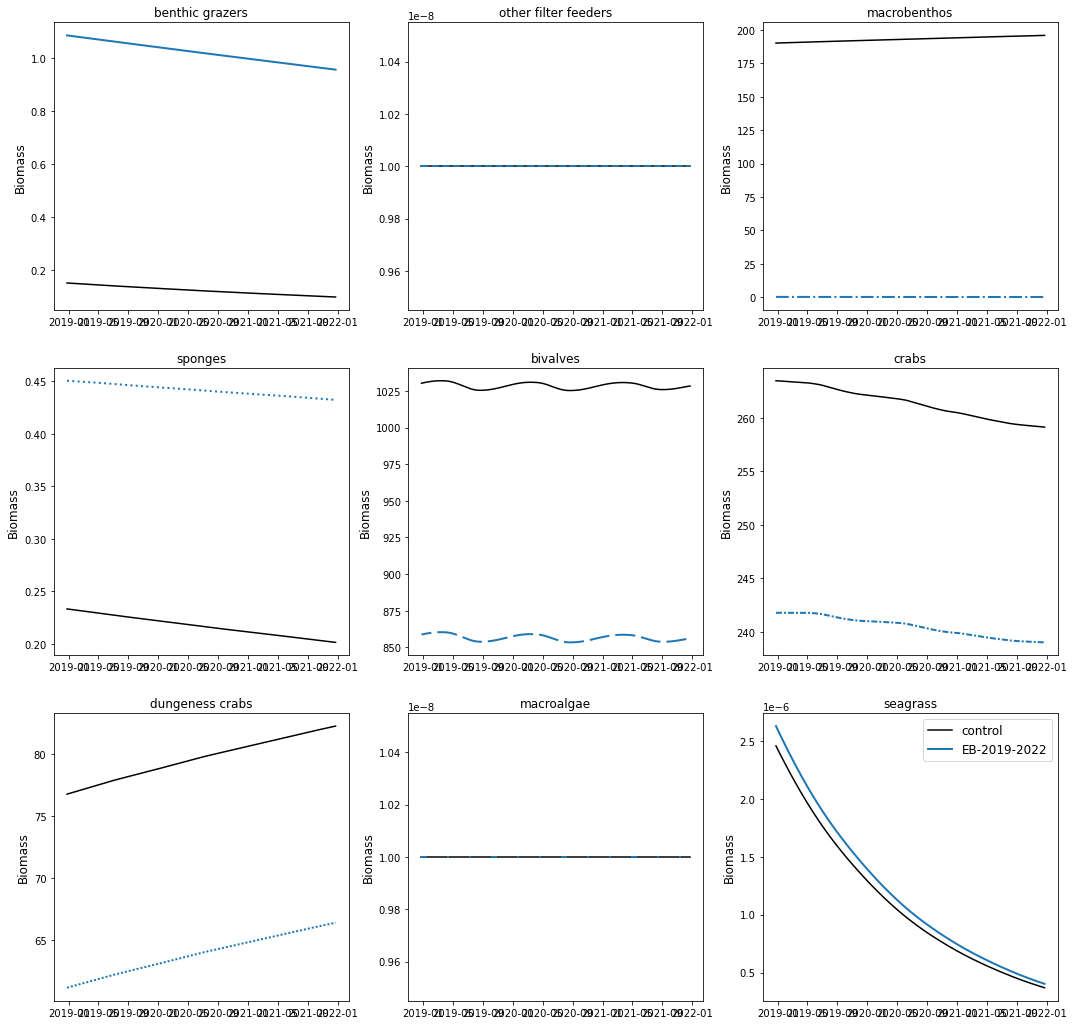

In [14]:
# 2019-2022 using mL to reduce biomass of benthic groups. But this method is not targetted enough to a spill in English Bay, as it would apply to the enture Salish Sea. 
plot_benthic_biomass(groups.benthos, scenario_datasets, scenario_paths, boxes=English_Bay)

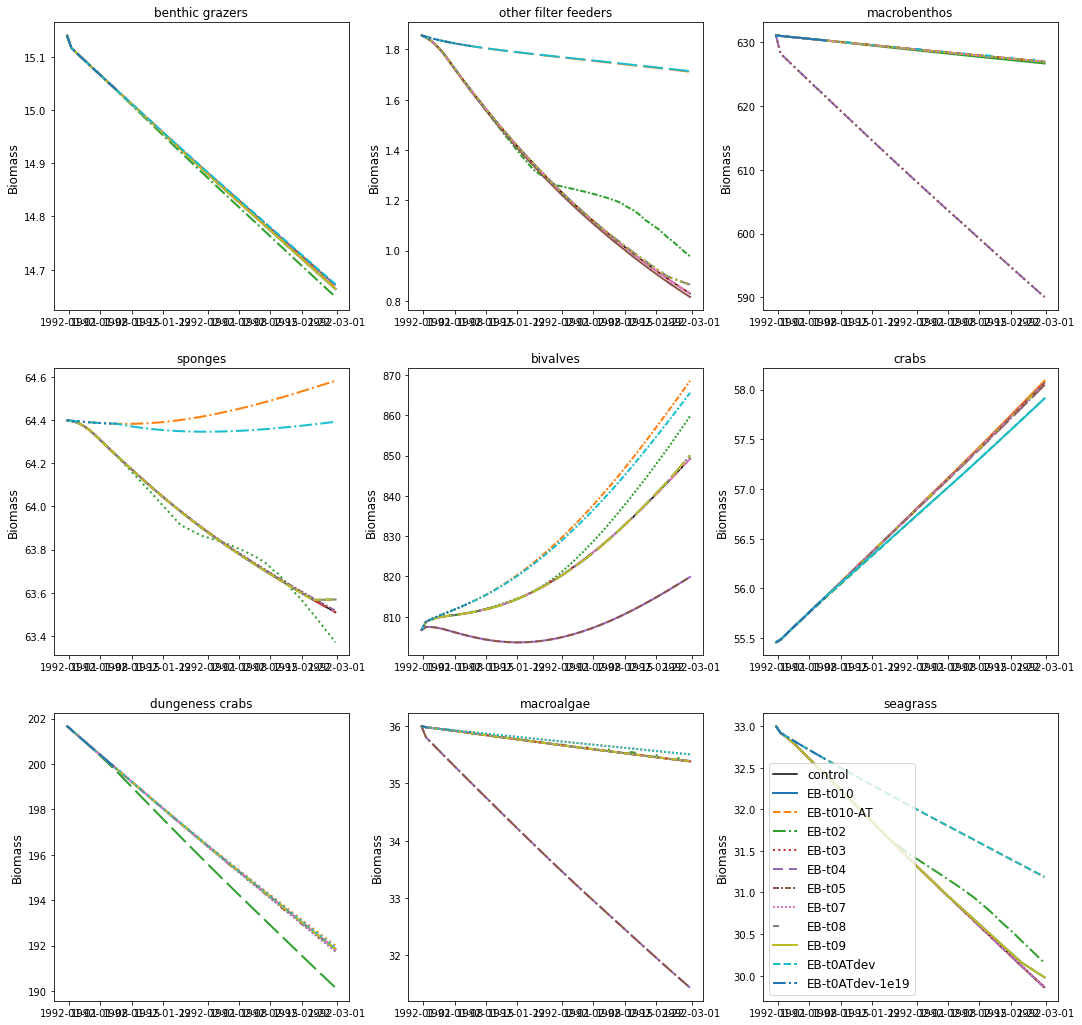

In [14]:
# All runs
plot_benthic_biomass(groups.benthos, scenario_datasets, scenario_paths, boxes=English_Bay)

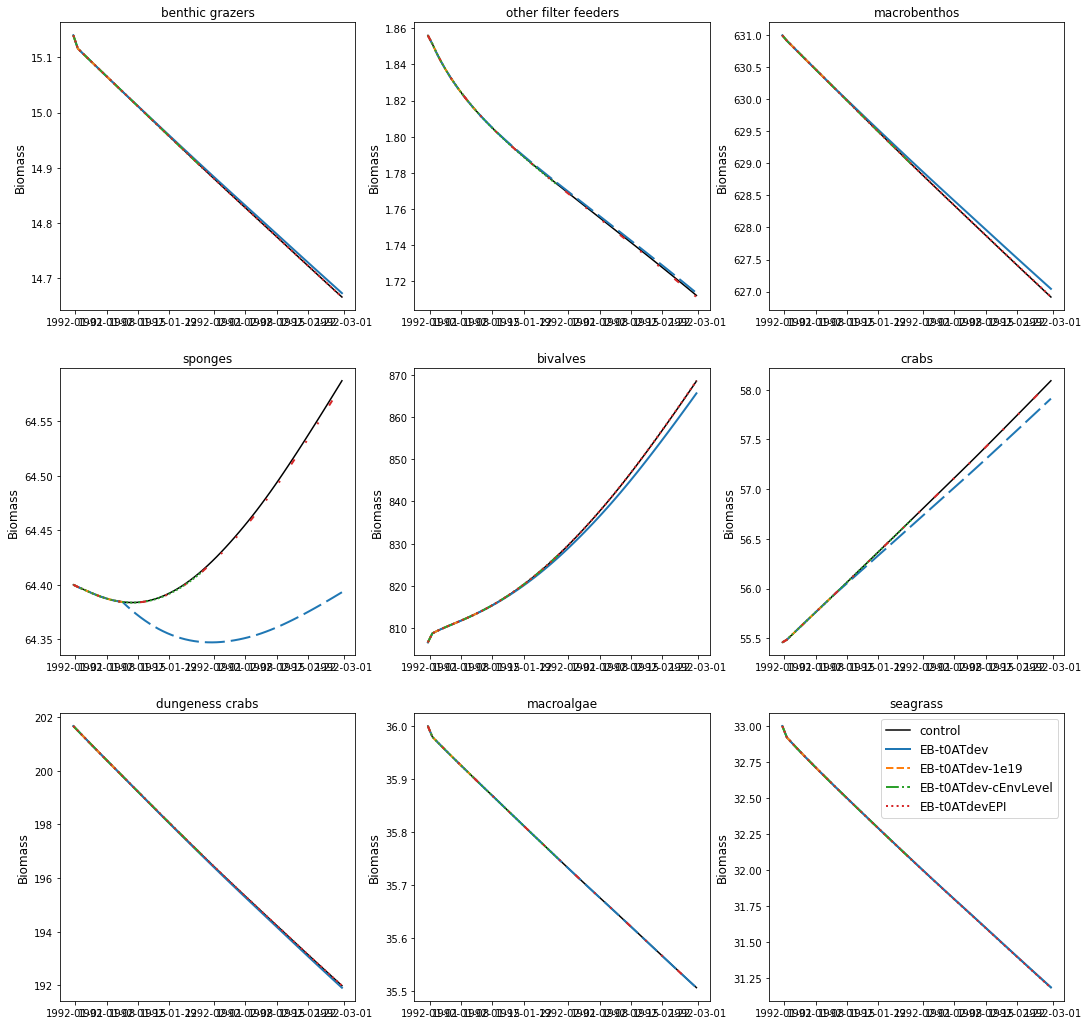

In [16]:
# Development Branch of Atlantis Code only
plot_benthic_biomass(groups.benthos, scenario_datasets, scenario_paths, boxes=English_Bay)

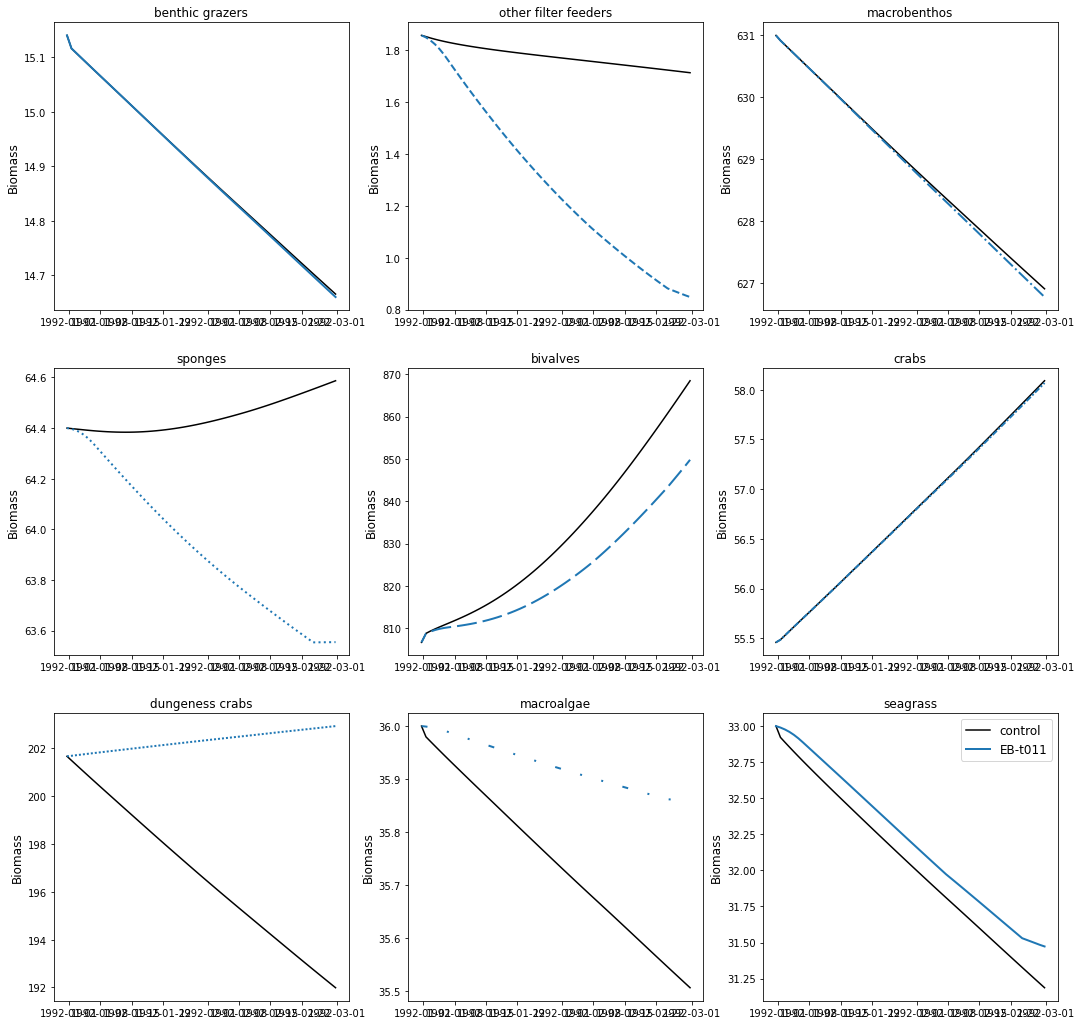

In [27]:
# Modified Atlantis Code v6719 to use clayer = 4 for determining cEnvLevel for benthos smothers
plot_benthic_biomass(groups.benthos, scenario_datasets[2:3], scenario_paths[2:3], boxes=English_Bay)

In [14]:
def plot_vert_biomass(bio_group, scenario_datasets, scenario_paths, control, boxes=groups.salish_sea, y_min=None, y_max=None):

    fig = plt.figure(figsize=(18, 18), facecolor='white')
    gs = plt.GridSpec(3, 3, wspace=0.2, hspace=0.2, width_ratios=[1,1,1], height_ratios=[1, 1, 1], )
    line_styles = itertools.cycle(('-', '--', '-.', ':',(5, (10, 3)),
    (0, (3, 1, 1, 1)),(0, (1, 1)),(0, (3, 10, 1, 10, 1, 10))))

    for species in bio_group:
        names = ['control']
        bio_index = (list(bio_group).index(species))
        if bio_index < 3:
            position = 0, bio_index
        elif bio_index > 5: 
            position = 2, bio_index-6
        else :
            position = 1, bio_index-3
        ax = fig.add_subplot(gs[position])

        numCohorts = groups.cohorts[bio_group[species]]
        
        for scenario, path in zip(scenario_datasets, scenario_paths):
            nm = str(path.parent.stem).split(sep='_')
            scenario_name = 'EB-'+nm[2]  
            names.append(scenario_name)

            for cohort in range (1, numCohorts+1):

                new_species = bio_group[species] + str(cohort)
                    #this_linestyle=next(line_styles)
            
                o_numbers_tbl = np.ma.filled(scenario.variables[new_species + '_Nums'][:, boxes, 0:6], np.nan)
                o_structuralN_tbl = np.ma.filled(scenario.variables[new_species +'_StructN'][:, boxes, 0:6], np.nan)
                o_reservedN_tbl = np.ma.filled(scenario.variables[new_species +'_ResN'][:, boxes, 0:6], np.nan)

                c_numbers_tbl = np.ma.filled(control.variables[new_species + '_Nums'][:, boxes, 0:6], np.nan)
                c_structuralN_tbl = np.ma.filled(control.variables[new_species +'_StructN'][:, boxes, 0:6], np.nan)
                c_reservedN_tbl = np.ma.filled(control.variables[new_species +'_ResN'][:, boxes, 0:6], np.nan)

                o_weightatage_tbl = (o_structuralN_tbl + o_reservedN_tbl) * o_numbers_tbl 
                o_weightatage = o_weightatage_tbl.sum(axis=(1,2))

                c_weightatage_tbl = (c_structuralN_tbl + c_reservedN_tbl) * c_numbers_tbl 
                c_weightatage = c_weightatage_tbl.sum(axis=(1,2))

                ax.plot(control.t, c_weightatage, linewidth = 2, color='black') #, label='control-'+scenario_name)
                ax.plot(scenario.t, o_weightatage, linewidth = 2, linestyle=':') #label=scenario_name, 
        ax.set_title(species)
        plt.ylabel('Biomass', fontsize=12)
        ax.set_ylim([y_min, y_max])
    ax.legend(names, fontsize=12, bbox_to_anchor=(1.05, 1)) #, loc='lower right'

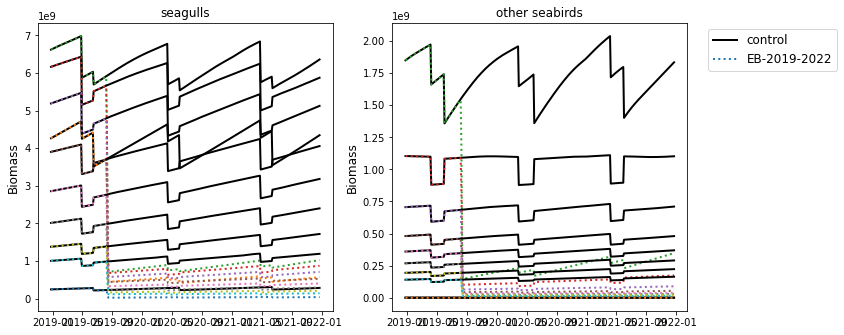

In [15]:
for control in control_datasets[0:1]:
    plot_vert_biomass(groups.birds, scenario_datasets[0:1], scenario_paths[0:1], control)

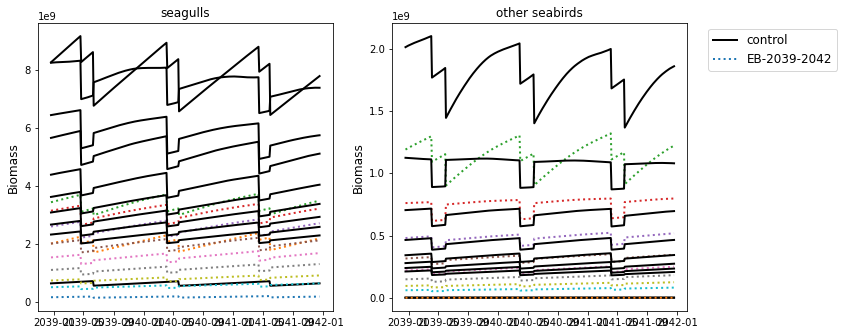

In [24]:
for control in control_datasets[2:3]:
    plot_vert_biomass(groups.birds, scenario_datasets[1:2], scenario_paths[1:2], control)

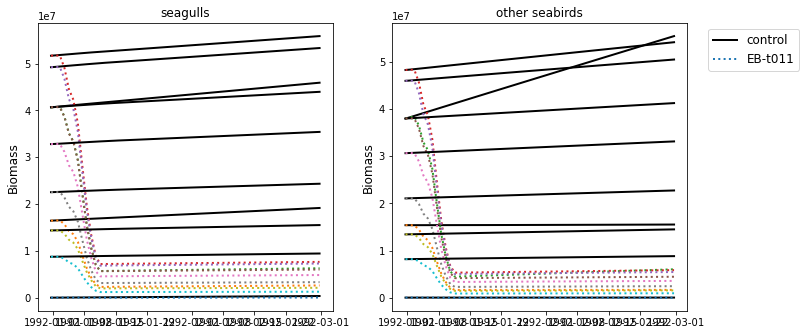

In [22]:
# EB-t08 is benzo impact on v6719
plot_vert_biomass(groups.birds, scenario_datasets[2:3], scenario_paths[2:3])

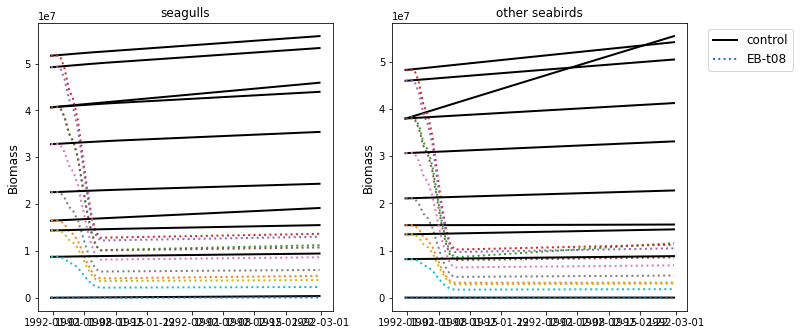

In [20]:
# EB-t08 is benzo impact on v6719
plot_vert_biomass(groups.birds, scenario_datasets[7:8], scenario_paths[7:8])

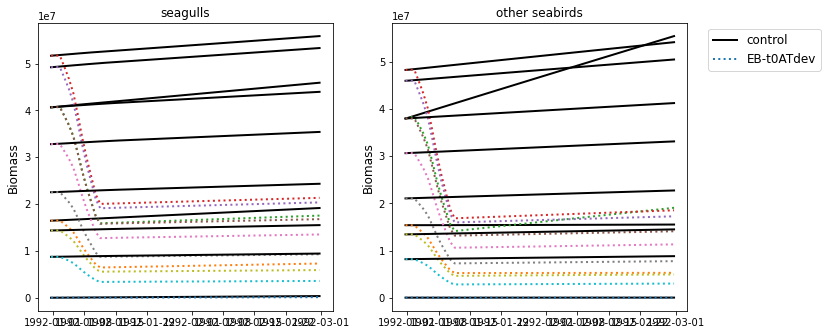

In [18]:
# Benzo impact on version AtlantisTrunk Dev on Github - only version where benthos takes in contaminants
plot_vert_biomass(groups.birds, scenario_datasets[9:10], scenario_paths[9:10])

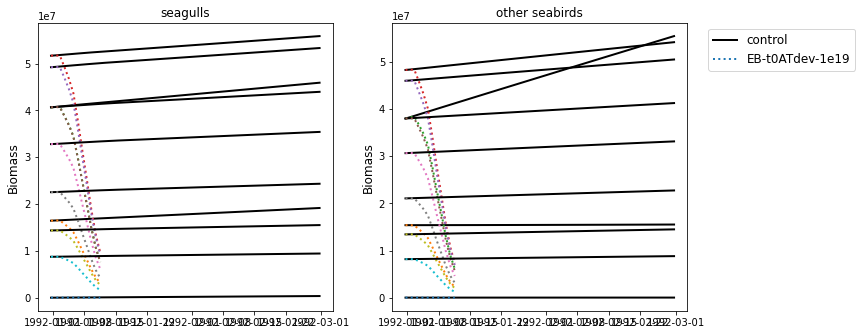

In [17]:
# Benzo impact on version AtlantisTrunk Dev on Github - only version where benthos takes in contaminants
plot_vert_biomass(groups.birds, scenario_datasets[10:11], scenario_paths[10:11])

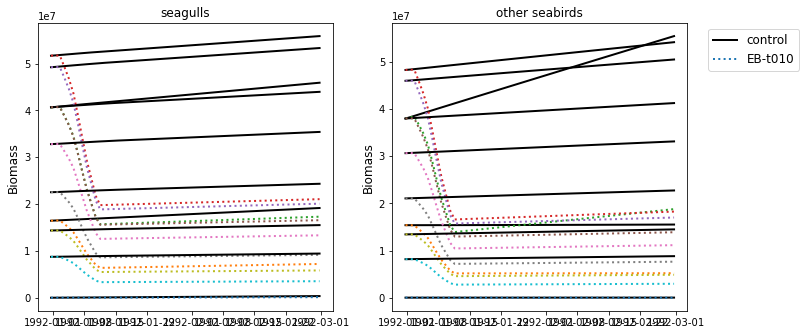

In [21]:
# Benzo impact on version 6721
plot_vert_biomass(groups.birds, scenario_datasets[1:2], scenario_paths[1:2])

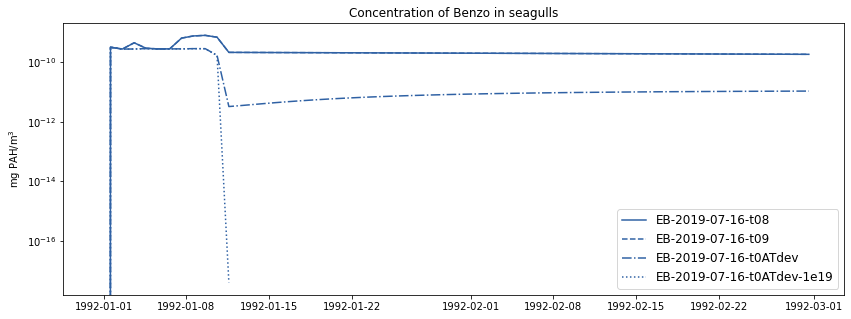

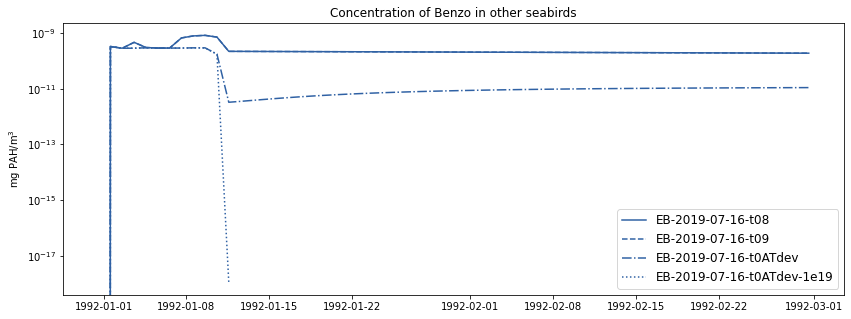

In [19]:
boxes = groups.salish_sea
for species in groups.birds:
    fig, ax = plt.subplots(figsize = (14,5))
    for scenario, name in zip(scenario_datasets[7:11],scenario_names[7:11]):
        contam_tbl = 0
        for cohort in range (1, groups.cohorts[groups.birds[species]]+1):
            contam_tbl = contam_tbl + scenario.variables[groups.birds[species]+str(cohort)+'_Benzo'][:,boxes,0:6]
        contam_t = contam_tbl.sum(axis=(1,2))
        if 'AP' in name:
            hex_colour = '#863092'
        elif 'TP' in name:
            hex_colour = '#6DB48E'
        elif 'EB' in name:
            hex_colour = '#2F61A4'
        elif 'JF' in name:
            hex_colour = '#A27170'
        ax.semilogy(scenario.t, contam_t, color=hex_colour, linestyle=next(line_styles))
    ax.set_title('Concentration of Benzo in '+ species, fontsize = 12)
    ax.set_ylabel('mg PAH/m$^3$')
    ax.legend(scenario_names[7:11], fontsize=12, ncol=1);

In [16]:
bio_group=groups.birds
location=groups.salish_sea
all_results = []
data_labels = ['spill year','20 years later']

for scenario, path in zip(scenario_datasets[0:1], scenario_paths[0:1]):
    control = control_datasets[0]
    nm = str(path.parent.stem).split(sep='_')
    year = str(nm[2])
    if nm[0] == '6a':
        scenario_name = 'EB-'+groups.conditions_with_letters[str(groups.simulations[groups.conditions[nm[1]]])]

    average_ratio = 0
    for species in bio_group:

        species_ratio = 0

        numCohorts = groups.cohorts[bio_group[species]]
        for cohort in range (1, numCohorts+1):
            new_species = bio_group[species] + str(cohort)
        
            o_numbers_tbl = np.ma.filled(scenario.variables[new_species + '_Nums'][:, location, 0:6], np.nan)
            o_structuralN_tbl = np.ma.filled(scenario.variables[new_species +'_StructN'][:, location, 0:6], np.nan)
            o_reservedN_tbl = np.ma.filled(scenario.variables[new_species +'_ResN'][:, location, 0:6], np.nan)

            c_numbers_tbl = np.ma.filled(control.variables[new_species + '_Nums'][:, location, 0:6], np.nan)
            c_structuralN_tbl = np.ma.filled(control.variables[new_species +'_StructN'][:, location, 0:6], np.nan)
            c_reservedN_tbl = np.ma.filled(control.variables[new_species +'_ResN'][:, location, 0:6], np.nan)

            o_weightatage_tbl = (o_structuralN_tbl + o_reservedN_tbl) * o_numbers_tbl 
            o_weightatage = o_weightatage_tbl.sum(axis=(1,2)).mean()

            c_weightatage_tbl = (c_structuralN_tbl + c_reservedN_tbl) * c_numbers_tbl 
            c_weightatage = c_weightatage_tbl.sum(axis=(1,2)).mean()

            cohort_ratio = (o_weightatage / c_weightatage - 1) * 100
            #print(scenario_name, species, cohort, cohort_ratio)
            species_ratio = species_ratio + cohort_ratio

        final_species_ratio = species_ratio/numCohorts

        all_results.append({
        'bio_group': species,
        'time_label': 'spill year',
        'scenario': scenario_name,
        'percent_change': final_species_ratio,
        'sensitivity': groups.sensitivity[bio_group[species]],
        'sensitivity_negative': -groups.sensitivity[bio_group[species]],
        })

for scenario, path in zip(scenario_datasets[1:2], scenario_paths[1:2]):
    control = control_datasets[2]
    nm = str(path.parent.stem).split(sep='_')
    year = str(nm[2])
    if nm[0] == '6a':
        scenario_name = 'EB-'+groups.conditions_with_letters[str(groups.simulations[groups.conditions[nm[1]]])]
        
    average_ratio = 0
    for species in bio_group:

        species_ratio = 0

        numCohorts = groups.cohorts[bio_group[species]]
        for cohort in range (1, numCohorts+1):
            new_species = bio_group[species] + str(cohort)
        
            o_numbers_tbl = np.ma.filled(scenario.variables[new_species + '_Nums'][:, location, 0:6], np.nan)
            o_structuralN_tbl = np.ma.filled(scenario.variables[new_species +'_StructN'][:, location, 0:6], np.nan)
            o_reservedN_tbl = np.ma.filled(scenario.variables[new_species +'_ResN'][:, location, 0:6], np.nan)

            c_numbers_tbl = np.ma.filled(control.variables[new_species + '_Nums'][:, location, 0:6], np.nan)
            c_structuralN_tbl = np.ma.filled(control.variables[new_species +'_StructN'][:, location, 0:6], np.nan)
            c_reservedN_tbl = np.ma.filled(control.variables[new_species +'_ResN'][:, location, 0:6], np.nan)

            o_weightatage_tbl = (o_structuralN_tbl + o_reservedN_tbl) * o_numbers_tbl 
            o_weightatage = o_weightatage_tbl.sum(axis=(1,2)).mean()

            c_weightatage_tbl = (c_structuralN_tbl + c_reservedN_tbl) * c_numbers_tbl 
            c_weightatage = c_weightatage_tbl.sum(axis=(1,2)).mean()

            cohort_ratio = (o_weightatage / c_weightatage - 1) * 100
            #print(scenario_name, species, cohort, cohort_ratio)
            species_ratio = species_ratio + cohort_ratio

        final_species_ratio = species_ratio/numCohorts
        
        all_results.append({
        'bio_group': species,
        'time_label': '20 years later',
        'scenario': scenario_name,
        'percent_change': final_species_ratio,
        'sensitivity': groups.sensitivity[bio_group[species]],
        'sensitivity_negative': -groups.sensitivity[bio_group[species]],
        })

    df = pd.DataFrame(all_results)
    df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/Smother-test/smother-test-data-birds.csv")

In [17]:
bio_group=groups.benthos
location=groups.salish_sea
all_results = []
data_labels = ['spill year', '20 years later']

for scenario, path in zip(scenario_datasets[0:1], scenario_paths[0:1]):
    control = control_datasets[0]
    nm = str(path.parent.stem).split(sep='_')
    year = str(nm[2])
    if nm[0] == '6a':
        scenario_name = 'EB-'+groups.conditions_with_letters[str(groups.simulations[groups.conditions[nm[1]]])]

    for species in bio_group: 
        p_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][:, location], np.nan)
        p_control = np.ma.filled(control.variables[bio_group[species] + '_N'][:, location], np.nan)
    
        p_oiled = p_oiled.sum(axis=1).mean()+groups.base_biomass[bio_group[species]]
        p_control = p_control.sum(axis=1).mean()+groups.base_biomass[bio_group[species]]
        p_ratio = (p_oiled / p_control - 1) * 100

        all_results.append({
        'bio_group': species,
        'time_label': 'spill year',
        'scenario': scenario_name,
        'percent_change': p_ratio,
        'sensitivity': groups.sensitivity[bio_group[species]],
        'sensitivity_negative': -groups.sensitivity[bio_group[species]],
        })

for scenario, path in zip(scenario_datasets[1:2], scenario_paths[1:2]):
    control = control_datasets[2]
    nm = str(path.parent.stem).split(sep='_')
    year = str(nm[2])
    if nm[0] == '6a':
        scenario_name = 'EB-'+groups.conditions_with_letters[str(groups.simulations[groups.conditions[nm[1]]])]

    for species in bio_group: 
        p_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][:, location], np.nan)
        p_control = np.ma.filled(control.variables[bio_group[species] + '_N'][:, location], np.nan)
    
        p_oiled = p_oiled.sum(axis=1).mean()+groups.base_biomass[bio_group[species]]
        p_control = p_control.sum(axis=1).mean()+groups.base_biomass[bio_group[species]]
        p_ratio = (p_oiled / p_control - 1) * 100
        
        all_results.append({
        'bio_group': species,
        'time_label': '20 years later',
        'scenario': scenario_name,
        'percent_change': p_ratio,
        'sensitivity': groups.sensitivity[bio_group[species]],
        'sensitivity_negative': -groups.sensitivity[bio_group[species]],
        })

    df = pd.DataFrame(all_results)
    df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/Smother-test/smother-test-data-benthos.csv")

In [18]:
results_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/Smother-test')
results_paths = sorted([p for p in results_root.glob('smother-test-data-*.csv')])
smother_data = []
for file in results_paths:
    df1 = pd.read_csv(file)
    smother_data.append(df1[['bio_group', 'time_label','scenario', 'percent_change','sensitivity','sensitivity_negative']])

averaged_data_df = pd.concat(smother_data, ignore_index=True)
averaged_data_df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/Smother-test/smother_data.csv")

In [40]:
df = pd.read_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/Smother-test/smother_data.csv")

In [41]:
time_labels = df['time_label'].unique()
scenarios = df['scenario'].unique()
bio_groups = df['bio_group'].unique()

hatches = ['oo', '///', 'xx', '++']
alphas = [0.5, 0.75, 0.3, 1]
hex_colour = '#2F61A4'

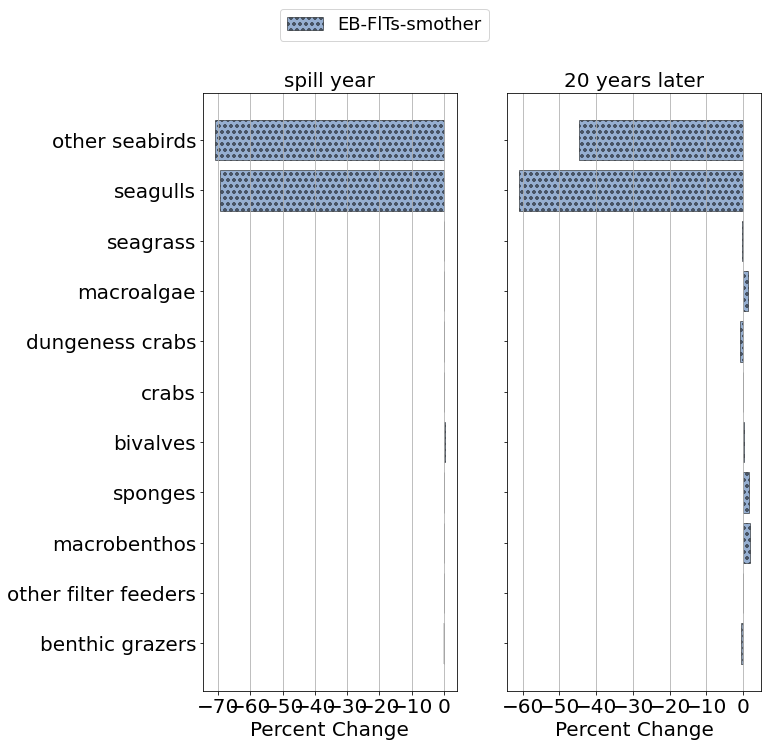

In [42]:
x_lim = None
df_plot = []
n_rows = len(bio_groups)
n_cols = len(time_labels)

fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, n_rows), sharey=True)

if n_cols == 1:
    axes = [axes]  

bar_width = 0.8 / len(scenarios)  
y_pos = np.arange(len(bio_groups))

for i, time in enumerate(time_labels):
    ax = axes[i]
    for j, scenario in enumerate(scenarios):
        df_plot = df[(df['time_label'] == time) & (df['scenario'] == scenario)]
        df_plot = df_plot.set_index('bio_group').reindex(bio_groups)  
        offset = (j - len(scenarios)/2) * bar_width + bar_width/2

        ax.barh(y_pos + offset, df_plot['percent_change'], height=bar_width, label=scenario, facecolor=hex_colour, alpha=alphas[j], edgecolor='black', hatch=hatches[j])
    ax.barh(bio_groups, df_plot['sensitivity'], label=scenario, color='grey', alpha=0.3)
    ax.barh(bio_groups, df_plot['sensitivity_negative'], label=scenario, color='grey', alpha=0.3)
    ax.xaxis.grid(True)
    xlabels = ax.get_xticklabels()
    plt.setp(xlabels, fontsize=20)

    ax.set_title(time, fontsize=20)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(bio_groups, fontsize=20) 
    ax.set_xlim(x_lim)
    ax.set_xlabel("Percent Change", fontsize=20)

fig.legend(scenarios, loc='upper center', ncol=len(scenarios), fontsize=18) 
fig.savefig("Figures/smother-test-results.png", dpi=300, bbox_inches='tight')  
plt.show()

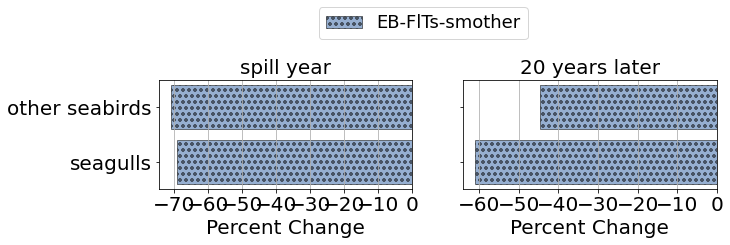

In [53]:
x_lim = None
df_plot = []
bio_groups = groups.birds
n_rows = len(bio_groups)
n_cols = len(time_labels)

fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, n_rows), sharey=True)

if n_cols == 1:
    axes = [axes]  

bar_width = 0.8 / len(scenarios)  
y_pos = np.arange(len(bio_groups))

for i, time in enumerate(time_labels):
    ax = axes[i]
    for j, scenario in enumerate(scenarios):
        df_plot = df[(df['time_label'] == time) & (df['scenario'] == scenario)]
        df_plot = df_plot.set_index('bio_group').reindex(bio_groups)  
        offset = (j - len(scenarios)/2) * bar_width + bar_width/2

        ax.barh(y_pos + offset, df_plot['percent_change'], height=bar_width, label=scenario, facecolor=hex_colour, alpha=alphas[j], edgecolor='black', hatch=hatches[j])
    ax.xaxis.grid(True)
    xlabels = ax.get_xticklabels()
    plt.setp(xlabels, fontsize=20)

    ax.set_title(time, fontsize=20)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(bio_groups, fontsize=20) 
    ax.set_xlim(x_lim)
    ax.set_xlabel("Percent Change", fontsize=20)

fig.legend(scenarios, ncol=1, fontsize=18, bbox_to_anchor=(0.65, 1.45)) 
fig.savefig("Figures/smother-test-results.png", dpi=300, bbox_inches='tight')  
plt.show()